In [ ]:
!pip install -q -U google-genai pandas scikit-learn sentence-transformers umap-learn hdbscan tqdm wordcloud squarify networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.9/750.9 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 223.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 228.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.1 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.1 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.1 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, bu

In [ ]:
from google.colab import drive
import os
import shutil
import glob

drive.mount('/content/drive')

drive_path = '/content/drive/My Drive/LLooM_ops'

Mounted at /content/drive


In [ ]:
if os.path.exists(drive_path):
    files_to_download = glob.glob(os.path.join(drive_path, '*'))

    print(f"📥 Found {len(files_to_download)} files in Drive. Starting download...")

    downloaded_files = []
    for file_path in files_to_download:
        fname = os.path.basename(file_path)
        try:
            shutil.copy2(file_path, os.path.join('/content/lloom_gemini_sv_outputs', fname))
            downloaded_files.append(fname)
        except Exception as e:
            print(f"❌ Error downloading {fname}: {e}")
    print("\n" + "="*40)
    print(f"✅ DOWNLOAD COMPLETE: {len(downloaded_files)} files restored")
    print("="*40)

    for i, name in enumerate(sorted(downloaded_files), 1):
        print(f"{i}. {name}")
else:
    print(f"⚠️ Folder not found: {drive_path}. Check your path name.")

📥 Found 14 files in Drive. Starting download...

✅ DOWNLOAD COMPLETE: 14 files restored
1. stigma_concept_summary.csv
2. stigma_concepts.csv
3. stigma_distill_checkpoint.jsonl
4. stigma_distilled_bullets.csv
5. stigma_score_checkpoint.jsonl
6. stigma_scores.csv
7. support_concept_summary.csv
8. support_concepts.csv
9. support_distill_checkpoint.jsonl
10. support_distilled_bullets.csv
11. support_score_checkpoint.jsonl
12. support_scores.csv
13. top_stigma_concepts.pdf
14. top_support_concepts.pdf


#Imports

In [ ]:
import re
import json
import time
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

from google.genai import types

from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from wordcloud import WordCloud
import squarify
import networkx as nx

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
import json
import pandas as pd
from google.cloud import storage
from google.cloud import aiplatform

# Load stigma and support datasets

In [ ]:
STIGMA_PATH = "/content/Sexual Violence sampled data - L3_dataset.csv"
SUPPORT_PATH = "/content/Sexual Violence sampled data - Support predictions full dataset.csv"

TEXT_COL = "body"   # change this if your text column has a different name

OUTPUT_DIR = "/content/lloom_gemini_sv_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# Models
# =========================
MODEL_FLASH = "gemini-2.0-flash"

MODEL_DISTILL = MODEL_FLASH
MODEL_SYNTH   = MODEL_FLASH
MODEL_SCORE   = MODEL_FLASH

# =========================
# Sexual violence seed phrases
# =========================
STIGMA_SEED = "types of stigma, blame, shame, disbelief, silencing, and social judgment in sexual violence-related Reddit discussions"
SUPPORT_SEED = "types of emotional, informational, practical, and community-based support in sexual violence-related Reddit discussions"

print("Output dir:", OUTPUT_DIR)
print("Using model:", MODEL_FLASH)
print("Stigma seed:", STIGMA_SEED)
print("Support seed:", SUPPORT_SEED)

stigma_df = pd.read_csv(STIGMA_PATH)
support_df = pd.read_csv(SUPPORT_PATH)

print("Stigma shape:", stigma_df.shape)
print("Support shape:", support_df.shape)

display(stigma_df.head())
display(support_df.head())

Output dir: /content/lloom_gemini_sv_outputs
Using model: gemini-2.0-flash
Stigma seed: types of stigma, blame, shame, disbelief, silencing, and social judgment in sexual violence-related Reddit discussions
Support seed: types of emotional, informational, practical, and community-based support in sexual violence-related Reddit discussions
Stigma shape: (2818, 22)
Support shape: (4631, 36)


,body,l2_json,l2_label,l2_reason,l2_evidence,l3_json,l3_json_obj,l3_blocked_any,l3_covered,Experienced_present,...,Internalized_present,Internalized_evidence,Internalized_reasoning,Anticipated_present,Anticipated_evidence,Anticipated_reasoning,Structural_present,Structural_evidence,Structural_reasoning,l3_labels
0,I (f23) was friends with a guy with whom I had...,"{'label': 'Stigma', 'reason': 'The victim is b...",Stigma,The victim is being blamed and minimized by th...,He keeps saying I'm blowing things out of prop...,"{""label_presence"": {""Experienced"": true, ""Inte...","{'label_presence': {'Experienced': True, 'Inte...",False,True,True,...,True,Am I blowing it out of proportion? Was it actu...,The survivor questions if she is blowing thing...,False,NaN,The post does not contain explicit or implicit...,False,NaN,The post describes a personal experience of un...,"Experienced, Internalized"
1,I don’t know if this is workplace sexual haras...,"{'label': 'Stigma', 'reason': 'The poster felt...",Stigma,The poster felt violated and depressed after t...,it upset me so much I felt violated and depressed,"{""label_presence"": {""Experienced"": true, ""Inte...","{'label_presence': {'Experienced': True, 'Inte...",False,True,True,...,True,it upset me so much I felt violated and depressed,The survivor expresses feeling violated and de...,True,I don’t know if this is workplace sexual haras...,The post describes a woman being harassed at w...,True,basically everyone including my supervisors kn...,The post describes a woman being harassed at w...,"Experienced, Internalized, Anticipated, Struct..."
2,What can my friend do about being sexually har...,"{'label': 'Stigma', 'reason': 'The post descri...",Stigma,The post describes a structural barrier where ...,She is 17 and has been told by her boss that s...,"{""label_presence"": {""Experienced"": true, ""Inte...","{'label_presence': {'Experienced': True, 'Inte...",False,True,True,...,False,NaN,The post describes a friend's experience of se...,False,NaN,The post describes a friend being sexually har...,False,NaN,The post describes a situation of sexual haras...,Experienced
3,I had a good conversation with a guy that I ju...,"{'label': 'Stigma', 'reason': ""The poster expr...",Stigma,The poster expresses internalized stigma by fe...,I can't help but feel extremely guilty about t...,"{""label_presence"": {""Experienced"": false, ""Int...","{'label_presence': {'Experienced': False, 'Int...",False,True,False,...,True,I can't help but feel extremely guilty about t...,The survivor expresses feelings of guilt and s...,False,NaN,"The post describes an uncomfortable encounter,...",False,NaN,The post describes a personal experience of un...,Internalized
4,also another instance with a completely differ...,"{'label': 'Stigma', 'reason': ""The poster's bo...",Stigma,"The poster's boundaries are being violated, an...",they know i don’t like when they touch me yet ...,"{""label_presence"": {""Experienced"": true, ""Inte...","{'label_presence': {'Experienced': True, 'Inte...",False,True,True,...,False,NaN,"The survivor does not express self-blame, sham...",True,i’ve told them they’re too close last time and...,The post describes a situation where the autho...,False,NaN,The post describes unwanted physical contact b...,"Experienced, Anticipated"


,post_id,subreddit,post_title,post_url,post_body,comment_id,author,body,created_utc,score,...,Esteem_Support_reasoning,Tangible_Assistance_present,Tangible_Assistance_evidence,Tangible_Assistance_reasoning,Group_Interaction_present,Group_Interaction_evidence,Group_Interaction_reasoning,None_present,None_evidence,None_reasoning
0,om798f,SexualHarassment,I'm not sure if I was sexually harassed or abu...,https://www.reddit.com/r/SexualHarassment/comm...,I (f23) was friends with a guy with whom I had...,h5j5kk8,gacGGE,I wouldn't forgive him but I'm not you. He say...,1626540383,2,...,The comment includes a statement that devalues...,False,NaN,The comment does not offer direct personal ass...,False,NaN,The comment does not contain any explicit grou...,False,NaN,NaN
1,ol3l81,SexualHarassment,[deleted by user],https://www.reddit.com/r/SexualHarassment/comm...,I don’t know if this is workplace sexual haras...,h5bz1on,gacGGE,If it was an ex boyfriend it would be classifi...,1626389826,1,...,The comment suggests a way to handle the situa...,False,NaN,The comment does not offer direct personal ass...,False,NaN,The comment does not contain any explicit grou...,False,NaN,NaN
2,ojmgbg,SexualHarassment,Serious help for a friend,https://www.reddit.com/r/SexualHarassment/comm...,What can my friend do about being sexually har...,h52l5q5,queenrothko,Hey. That is illegal and you should inform the...,1626204661,1,...,The comment expresses sympathy but does not co...,False,NaN,The comment does not offer direct personal ass...,False,NaN,The comment expresses sympathy but does not co...,False,NaN,NaN
3,ojmgbg,SexualHarassment,Serious help for a friend,https://www.reddit.com/r/SexualHarassment/comm...,What can my friend do about being sexually har...,h5314q6,queenrothko,If your friend needs free legal advice and sup...,1626211900,1,...,The comment provides information and resources...,True,you can contact rightsofwomen.org.uk or citize...,The comment directs the user to resources for ...,False,NaN,The comment primarily offers information and r...,False,NaN,NaN
4,ojkjeq,SexualHarassment,Am I in the wrong?,https://www.reddit.com/r/SexualHarassment/comm...,I had a good conversation with a guy that I ju...,h52fift,Familiar-Soft7902,"No, from the sound of it, you gave him exactly...",1626202162,2,...,The comment validates the recipient's feelings...,False,NaN,The comment does not offer direct personal ass...,False,NaN,The comment does not contain any explicit grou...,False,NaN,NaN


# Text Cleaning

In [ ]:
def clean_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"http\S+|www\S+", " ", x)
    x = re.sub(r"&amp;|amp", " ", x)
    x = re.sub(r">+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

stigma_df = stigma_df.dropna(subset=[TEXT_COL]).copy()
support_df = support_df.dropna(subset=[TEXT_COL]).copy()

stigma_df["clean_text"] = stigma_df[TEXT_COL].astype(str).apply(clean_text)
support_df["clean_text"] = support_df[TEXT_COL].astype(str).apply(clean_text)

# Remove only empty strings
stigma_df = stigma_df[stigma_df["clean_text"].str.strip() != ""].copy()
support_df = support_df[support_df["clean_text"].str.strip() != ""].copy()

print("After cleaning:")
print("stigma:", stigma_df.shape)
print("support:", support_df.shape)

After cleaning:
stigma: (2818, 23)
support: (4630, 37)


In [ ]:
bot_patterns = [
    "if you or someone you know is contemplating suicide",
    "please reach out to",
    "reddit help resources",
    "this post has been removed",
    "contact the moderators",
    "subreddit rules",
    "performed automatically",
    "i am a bot",
    "was performed automatically"
]

bot_regex = "|".join(bot_patterns)

support_df = support_df[
    ~support_df["clean_text"].str.contains(bot_regex, case=False, na=False)
].copy()

print("After bot/mod filtering:")
print("stigma:", stigma_df.shape)
print("support:", support_df.shape)

After bot/mod filtering:
stigma: (2818, 23)
support: (4466, 37)


In [ ]:
def safe_json_load(text):
    text = str(text).strip()

    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    try:
        return json.loads(text)
    except Exception:
        pass

    m = re.search(r"\{.*\}", text, re.DOTALL)
    if m:
        return json.loads(m.group(0))

    raise ValueError(f"Could not parse JSON from response:\n{text[:1200]}")

In [ ]:
def gemini_json(prompt, model_name, temperature=0.2):
    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=temperature,
            response_mime_type="application/json"
        )
    )
    return safe_json_load(response.text)

# Distill one text into 2–4 short bullets

In [ ]:
def distill_text_to_bullets(text, seed_phrase=""):
    prompt = f"""
You will read one Reddit text and summarize its main points into 2 to 4 short bullet phrases.

Rules:
- Each bullet must be 5 to 10 words
- Focus on the most salient meaning
- Avoid generic phrases
- Avoid repeating the same idea
- Keep wording concise
- Use the analytic focus only as a lens, not as a reason to invent content
- Return valid JSON only

Analytic focus:
{seed_phrase if seed_phrase else "None"}

Return format:
{{
  "bullets": ["...", "..."]
}}

TEXT:
{text}
"""
    obj = gemini_json(prompt, MODEL_DISTILL, temperature=0.2)
    bullets = obj.get("bullets", [])
    bullets = [str(b).strip() for b in bullets if str(b).strip()]
    return bullets[:4]

In [ ]:
def _distill_one(idx, txt, seed_phrase="", max_retries=3, sleep_seconds=2):
    for attempt in range(max_retries):
        try:
            bullets = distill_text_to_bullets(txt, seed_phrase=seed_phrase)
            return {
                "orig_index": idx,
                "text": txt,
                "bullets": bullets,
                "error": None
            }
        except Exception as e:
            err = str(e)
            if attempt < max_retries - 1:
                time.sleep(sleep_seconds * (attempt + 1))
            else:
                return {
                    "orig_index": idx,
                    "text": txt,
                    "bullets": None,
                    "error": err
                }

def run_distillation_parallel_checkpointed(
    df,
    text_col="clean_text",
    sample_limit=None,
    seed_phrase="",
    max_workers=4,
    max_retries=3,
    checkpoint_path="distill_checkpoint.jsonl"
):
    rows = []
    done_ids = set()

    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            for line in f:
                rec = json.loads(line)
                rows.append(rec)
                done_ids.add(rec["orig_index"])

    work_df = df.copy()
    if sample_limit is not None:
        work_df = work_df.sample(sample_limit, random_state=42)

    items = [
        (idx, row[text_col])
        for idx, row in work_df.iterrows()
        if idx not in done_ids
    ]

    print(f"Already completed: {len(done_ids)}")
    print(f"Remaining: {len(items)}")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(_distill_one, idx, txt, seed_phrase, max_retries): idx
            for idx, txt in items
        }

        with open(checkpoint_path, "a") as fout:
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Distilling"):
                result = fut.result()
                fout.write(json.dumps(result) + "\n")
                fout.flush()
                rows.append(result)

    return pd.DataFrame(rows)

In [ ]:
stigma_distilled_raw = run_distillation_parallel_checkpointed(
    stigma_df,
    text_col="clean_text",
    sample_limit=None,
    seed_phrase=STIGMA_SEED,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/stigma_distill_checkpoint.jsonl"
)

support_distilled_raw = run_distillation_parallel_checkpointed(
    support_df,
    text_col="clean_text",
    sample_limit=None,
    seed_phrase=SUPPORT_SEED,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/support_distill_checkpoint.jsonl"
)

print("stigma_distilled_raw:", stigma_distilled_raw.shape)
print("support_distilled_raw:", support_distilled_raw.shape)

Already completed: 2818
Remaining: 0


Distilling: 0it [00:00, ?it/s]

Already completed: 4466
Remaining: 0


Distilling: 0it [00:00, ?it/s]

stigma_distilled_raw: (2818, 4)
support_distilled_raw: (4466, 4)


In [ ]:
def expand_distilled_rows(distilled_df):
    rows = []
    for _, row in distilled_df.iterrows():
        bullets = row.get("bullets")
        if isinstance(bullets, list):
            for b in bullets:
                rows.append({
                    "orig_index": row["orig_index"],
                    "text": row["text"],
                    "bullet": b,
                    "error": row.get("error")
                })
        else:
            rows.append({
                "orig_index": row["orig_index"],
                "text": row["text"],
                "bullet": None,
                "error": row.get("error")
            })
    return pd.DataFrame(rows)

stigma_distilled = expand_distilled_rows(stigma_distilled_raw)
support_distilled = expand_distilled_rows(support_distilled_raw)

stigma_distilled = stigma_distilled.dropna(subset=["bullet"]).copy()
support_distilled = support_distilled.dropna(subset=["bullet"]).copy()

print("Expanded stigma bullets:", stigma_distilled.shape)
print("Expanded support bullets:", support_distilled.shape)

stigma_distilled.to_csv(f"{OUTPUT_DIR}/stigma_distilled_bullets.csv", index=False)
support_distilled.to_csv(f"{OUTPUT_DIR}/support_distilled_bullets.csv", index=False)

Expanded stigma bullets: (9881, 4)
Expanded support bullets: (12820, 4)


In [ ]:
embedder = SentenceTransformer("all-mpnet-base-v2")

stigma_bullets = stigma_distilled["bullet"].tolist()
support_bullets = support_distilled["bullet"].tolist()

stigma_emb = embedder.encode(stigma_bullets, show_progress_bar=True)
support_emb = embedder.encode(support_bullets, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/309 [00:00<?, ?it/s]

Batches:   0%|          | 0/401 [00:00<?, ?it/s]

# Clustering Distilled Bullets

In [ ]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

clusterer = HDBSCAN(
    min_cluster_size=12,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

stigma_red = umap_model.fit_transform(stigma_emb)
support_red = umap_model.fit_transform(support_emb)

stigma_labels = clusterer.fit_predict(stigma_red)
support_labels = clusterer.fit_predict(support_red)

stigma_distilled["cluster"] = stigma_labels
support_distilled["cluster"] = support_labels

display(stigma_distilled["cluster"].value_counts().head(20))
display(support_distilled["cluster"].value_counts().head(20))

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster
-1      3660
 39      407
 5       295
 53      240
 1       211
 88      175
 74      167
 108     162
 52      141
 3       132
 19      125
 61      122
 85      106
 106      98
 76       86
 69       79
 107      78
 44       76
 37       76
 60       75
Name: count, dtype: int64

cluster
-1      5408
 164     316
 113     213
 168     174
 92      141
 81      110
 16       95
 177      93
 181      91
 80       90
 52       88
 89       88
 110      86
 167      82
 124      82
 137      81
 102      79
 128      78
 20       76
 153      74
Name: count, dtype: int64

In [ ]:
def show_cluster_examples(distilled_df, top_n_clusters=10, examples_per_cluster=8):
    counts = distilled_df[distilled_df["cluster"] != -1]["cluster"].value_counts().head(top_n_clusters)
    for cid in counts.index:
        print(f"\n===== CLUSTER {cid} | size={counts[cid]} =====")
        ex = distilled_df[distilled_df["cluster"] == cid]["bullet"].head(examples_per_cluster).tolist()
        for e in ex:
            print("-", e)

print("STIGMA CLUSTERS")
show_cluster_examples(stigma_distilled)

print("\nSUPPORT CLUSTERS")
show_cluster_examples(support_distilled)

STIGMA CLUSTERS

===== CLUSTER 39 | size=407 =====
- She fears ruining the instructor's life.
- She questions her clothing, fears his return.
- She felt disgusted and traumatized by the event.
- She blames herself for not leaving the relationship sooner.
- She felt obligated to stay due to his reliance.
- She experienced disbelief and silencing in the relationship.
- She blames herself, internalizing shame for not stopping him.
- She feels shame for her 'irresponsible' behavior.

===== CLUSTER 5 | size=295 =====
- Friend denies knowing OP was awake and aware.
- Victim remembers why she ended friendship previously.
- Friend's disbelief invalidates victim's feelings.
- Social judgment: victim questions if friend's actions were wrong.
- Disbelief: victim trusts friend, minimizes potential exploitation.
- Shame about bringing a friend into a toxic environment.
- Friend denies incident, causing confusion and self-doubt
- Disbelief that a 'good friend' could commit harassment.

===== CLUSTER

In [ ]:
def synthesize_concept(cluster_bullets, seed_phrase=""):
    bullets_text = "\n".join([f"- {b}" for b in cluster_bullets])

    prompt = f"""
You are inducing a high-level concept from a set of short bullet summaries from Reddit posts/comments.

Your job:
1. Propose one specific, human-interpretable concept
2. Write explicit inclusion criteria for when a text matches this concept
3. Avoid generic labels like "general discussion" or "emotion"
4. Make the concept concise but meaningful
5. Return valid JSON only

Analytic focus:
{seed_phrase if seed_phrase else "None"}

Return format:
{{
  "concept_name": "...",
  "description": "...",
  "inclusion_criteria": "...",
  "example_signals": ["...", "...", "..."]
}}

BULLETS:
{bullets_text}
"""
    obj = gemini_json(prompt, MODEL_SYNTH, temperature=0.2)
    return obj

In [ ]:
def build_concepts_from_clusters(distilled_df, top_n_clusters=10, max_bullets_per_cluster=20, seed_phrase=""):
    concepts = []
    counts = distilled_df[distilled_df["cluster"] != -1]["cluster"].value_counts().head(top_n_clusters)

    for cid in tqdm(counts.index, desc="Synthesizing concepts"):
        bullets = distilled_df[distilled_df["cluster"] == cid]["bullet"].dropna().tolist()
        bullets = bullets[:max_bullets_per_cluster]

        try:
            concept = synthesize_concept(bullets, seed_phrase=seed_phrase)
            concept["cluster"] = int(cid)
            concept["cluster_size"] = int(counts[cid])
            concepts.append(concept)
        except Exception as e:
            concepts.append({
                "cluster": int(cid),
                "cluster_size": int(counts[cid]),
                "concept_name": None,
                "description": None,
                "inclusion_criteria": None,
                "example_signals": None,
                "error": str(e)
            })

    return pd.DataFrame(concepts)

In [ ]:
stigma_concepts = build_concepts_from_clusters(
    stigma_distilled,
    top_n_clusters=10,
    max_bullets_per_cluster=20,
    seed_phrase=STIGMA_SEED
)

support_concepts = build_concepts_from_clusters(
    support_distilled,
    top_n_clusters=10,
    max_bullets_per_cluster=20,
    seed_phrase=SUPPORT_SEED
)

display(stigma_concepts)
display(support_concepts)

stigma_concepts.to_csv(f"{OUTPUT_DIR}/stigma_concepts.csv", index=False)
support_concepts.to_csv(f"{OUTPUT_DIR}/support_concepts.csv", index=False)

Synthesizing concepts:   0%|          | 0/10 [00:00<?, ?it/s]

Synthesizing concepts:   0%|          | 0/10 [00:00<?, ?it/s]

,cluster,cluster_size,concept_name,description,inclusion_criteria,example_signals,error
0,39,407,None,None,None,None,name 'client' is not defined
1,5,295,None,None,None,None,name 'client' is not defined
2,53,240,None,None,None,None,name 'client' is not defined
3,1,211,None,None,None,None,name 'client' is not defined
4,88,175,None,None,None,None,name 'client' is not defined
5,74,167,None,None,None,None,name 'client' is not defined
6,108,162,None,None,None,None,name 'client' is not defined
7,52,141,None,None,None,None,name 'client' is not defined
8,3,132,None,None,None,None,name 'client' is not defined
9,19,125,None,None,None,None,name 'client' is not defined


,cluster,cluster_size,concept_name,description,inclusion_criteria,example_signals,error
0,164,316,None,None,None,None,name 'client' is not defined
1,113,213,None,None,None,None,name 'client' is not defined
2,168,174,None,None,None,None,name 'client' is not defined
3,92,141,None,None,None,None,name 'client' is not defined
4,81,110,None,None,None,None,name 'client' is not defined
5,16,95,None,None,None,None,name 'client' is not defined
6,177,93,None,None,None,None,name 'client' is not defined
7,181,91,None,None,None,None,name 'client' is not defined
8,80,90,None,None,None,None,name 'client' is not defined
9,52,88,None,None,None,None,name 'client' is not defined


In [ ]:
def score_text_against_all_concepts(text, concepts_df):
    valid_concepts = concepts_df.dropna(subset=["concept_name", "inclusion_criteria"]).copy()

    concept_block = []
    for _, c in valid_concepts.iterrows():
        concept_block.append(
            f"Concept: {c['concept_name']}\nCriteria: {c['inclusion_criteria']}"
        )

    prompt = f"""
You will read one Reddit text and decide which concepts apply.

Return valid JSON only in this format:
{{
  "matches": [
    {{
      "concept_name": "...",
      "match": 0,
      "reason": "short reason"
    }}
  ]
}}

Important:
- Include one entry for every concept provided
- Use match = 1 only if the text clearly fits the concept criteria
- Otherwise use match = 0

Concepts:
{chr(10).join(concept_block)}

TEXT:
{text}
"""
    obj = gemini_json(prompt, MODEL_SCORE, temperature=0.1)
    return obj["matches"]

In [ ]:
def _score_one_text(idx, txt, concepts_df, max_retries=3, sleep_seconds=2):
    for attempt in range(max_retries):
        try:
            matches = score_text_against_all_concepts(txt, concepts_df)
            return {
                "orig_index": idx,
                "text": txt,
                "matches": matches,
                "error": None
            }
        except Exception as e:
            err = str(e)
            if attempt < max_retries - 1:
                time.sleep(sleep_seconds * (attempt + 1))
            else:
                return {
                    "orig_index": idx,
                    "text": txt,
                    "matches": None,
                    "error": err
                }

def score_dataset_against_concepts_checkpointed(
    df,
    concepts_df,
    text_col="clean_text",
    sample_limit=None,
    max_workers=4,
    max_retries=3,
    checkpoint_path="score_checkpoint.jsonl"
):
    rows = []
    done_ids = set()

    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            for line in f:
                rec = json.loads(line)
                rows.append(rec)
                done_ids.add(rec["orig_index"])

    work_df = df.copy()
    if sample_limit is not None:
        work_df = work_df.sample(sample_limit, random_state=42)

    items = [
        (idx, row[text_col])
        for idx, row in work_df.iterrows()
        if idx not in done_ids
    ]

    print(f"Already scored: {len(done_ids)}")
    print(f"Remaining: {len(items)}")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(_score_one_text, idx, txt, concepts_df, max_retries): idx
            for idx, txt in items
        }

        with open(checkpoint_path, "a") as fout:
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Scoring"):
                result = fut.result()
                fout.write(json.dumps(result) + "\n")
                fout.flush()
                rows.append(result)

    return pd.DataFrame(rows)

In [ ]:
stigma_scores_raw = score_dataset_against_concepts_checkpointed(
    stigma_df,
    stigma_concepts,
    text_col="clean_text",
    sample_limit=None,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/stigma_score_checkpoint.jsonl"
)

support_scores_raw = score_dataset_against_concepts_checkpointed(
    support_df,
    support_concepts,
    text_col="clean_text",
    sample_limit=None,
    max_workers=4,
    checkpoint_path=f"{OUTPUT_DIR}/support_score_checkpoint.jsonl"
)

print("stigma_scores_raw:", stigma_scores_raw.shape)
print("support_scores_raw:", support_scores_raw.shape)

Already scored: 2818
Remaining: 0


Scoring: 0it [00:00, ?it/s]

Already scored: 4466
Remaining: 0


Scoring: 0it [00:00, ?it/s]

stigma_scores_raw: (2818, 4)
support_scores_raw: (4466, 4)


In [ ]:
def expand_scored_rows(scored_df):
    rows = []
    for _, row in scored_df.iterrows():
        matches = row.get("matches")
        if isinstance(matches, list):
            for m in matches:
                rows.append({
                    "orig_index": row["orig_index"],
                    "text": row["text"],
                    "concept_name": m.get("concept_name"),
                    "match": m.get("match"),
                    "reason": m.get("reason"),
                    "error": row.get("error")
                })
        else:
            rows.append({
                "orig_index": row["orig_index"],
                "text": row["text"],
                "concept_name": None,
                "match": None,
                "reason": None,
                "error": row.get("error")
            })
    return pd.DataFrame(rows)

stigma_scores = expand_scored_rows(stigma_scores_raw)
support_scores = expand_scored_rows(support_scores_raw)

stigma_scores.to_csv(f"{OUTPUT_DIR}/stigma_scores.csv", index=False)
support_scores.to_csv(f"{OUTPUT_DIR}/support_scores.csv", index=False)

print(stigma_scores.shape)
print(support_scores.shape)

(28180, 6)
(44660, 6)


In [ ]:
def summarize_concept_coverage(scores_df):
    matched = scores_df[scores_df["match"] == 1].copy()
    by_concept = matched["concept_name"].value_counts().reset_index()
    by_concept.columns = ["concept_name", "matched_count"]
    return by_concept

stigma_concept_summary = summarize_concept_coverage(stigma_scores)
support_concept_summary = summarize_concept_coverage(support_scores)

display(stigma_concept_summary)
display(support_concept_summary)

stigma_concept_summary.to_csv(f"{OUTPUT_DIR}/stigma_concept_summary.csv", index=False)
support_concept_summary.to_csv(f"{OUTPUT_DIR}/support_concept_summary.csv", index=False)

,concept_name,matched_count
0,Internalized Self-Blame and Shame,1646
1,Internalized Blame and Self-Silencing After Se...,1587
2,Internalized Shame and Self-Blame After Unwant...,1578
3,Internalized Self-Blame and Minimization Follo...,1550
4,Internalized Stigma and Fear of Disclosure Aft...,1171
5,Intoxication as a Mitigating or Confusing Fact...,655
6,Intimacy Avoidance Due to Trauma,533
7,Friendship Betrayal and Invalidation in the Co...,365
8,Maternal Minimization and Justification of Abuse,180
9,Secondary Victimization by Partner,158


,concept_name,matched_count
0,Normalizing and Validating Trauma Responses Re...,1691
1,Experience Sharing for Solidarity and Support,1060
2,Promoting Consent Awareness and Education,835
3,Recommendation of Trauma-Focused Therapy,698
4,Seeking Support from Trusted Individuals,691
5,Empowering Survivor Identity,683
6,Encouragement and Discussion of Reporting Sexu...,566
7,Acknowledgement of Strength and Bravery in Sha...,412
8,Signposting to Resources for Sexual Assault Su...,389
9,Challenging Intoxication as a Mitigating Facto...,152


# Example extraction

In [ ]:
def build_concept_example_table(scores_df, summary_df, top_n=10):
    # Get top concepts
    top_concepts = summary_df.sort_values("matched_count", ascending=False).head(top_n)

    rows = []

    for _, row in top_concepts.iterrows():
        concept = row["concept_name"]

        # Get one example text for that concept
        example_row = scores_df[
            (scores_df["concept_name"] == concept) & (scores_df["match"] == 1)
        ]

        example_text = ""
        if len(example_row) > 0:
            example_text = example_row.iloc[0]["text"]

        rows.append({
            "Concept": concept,
            "Example": example_text
        })

    return pd.DataFrame(rows)

In [ ]:
stigma_post_table = build_concept_example_table(
    stigma_scores,
    stigma_concept_summary,
    top_n=10
)

In [ ]:
support_table = build_concept_example_table(
    support_scores,
    support_concept_summary,
    top_n=10
)

In [ ]:
# def clean_example(text, max_len=180):
#     text = str(text).replace("\n", " ")
#     return text[:max_len] + "..." if len(text) > max_len else text

# DO NOT truncate for CSV
stigma_post_table_full = stigma_post_table.copy()
support_table_full = support_table.copy()

In [ ]:
stigma_post_table_full.to_csv(f"{OUTPUT_DIR}/stigma_post_concepts_table.csv", index=False)
support_table_full.to_csv(f"{OUTPUT_DIR}/support_concepts_table.csv", index=False)

In [ ]:
import textwrap
import matplotlib.pyplot as plt

def wrap_labels(labels, width=40):
    return ["\n".join(textwrap.wrap(str(label), width=width)) for label in labels]


def concept_barplot(df, title, top_n=10, save_path=None):

    plot_df = df.sort_values("matched_count", ascending=False).head(top_n).copy()
    plot_df = plot_df.iloc[::-1]

    wrapped = wrap_labels(plot_df["concept_name"], width=45)

    plt.figure(figsize=(12, 7))
    plt.barh(wrapped, plot_df["matched_count"])
    plt.yticks(fontweight='bold')
    plt.xlabel("Count", fontweight='bold')
    plt.ylabel("Concept",fontweight='bold')
    plt.title(title,fontweight='bold')

    plt.tight_layout()

    # Save if path provided
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

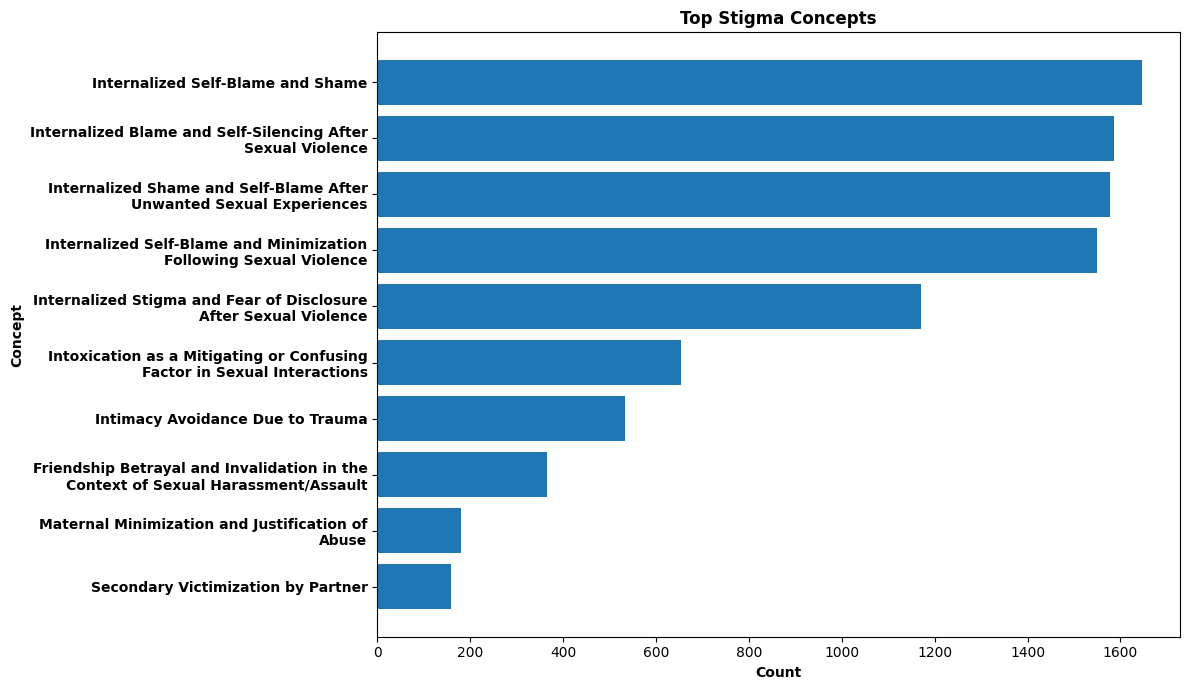

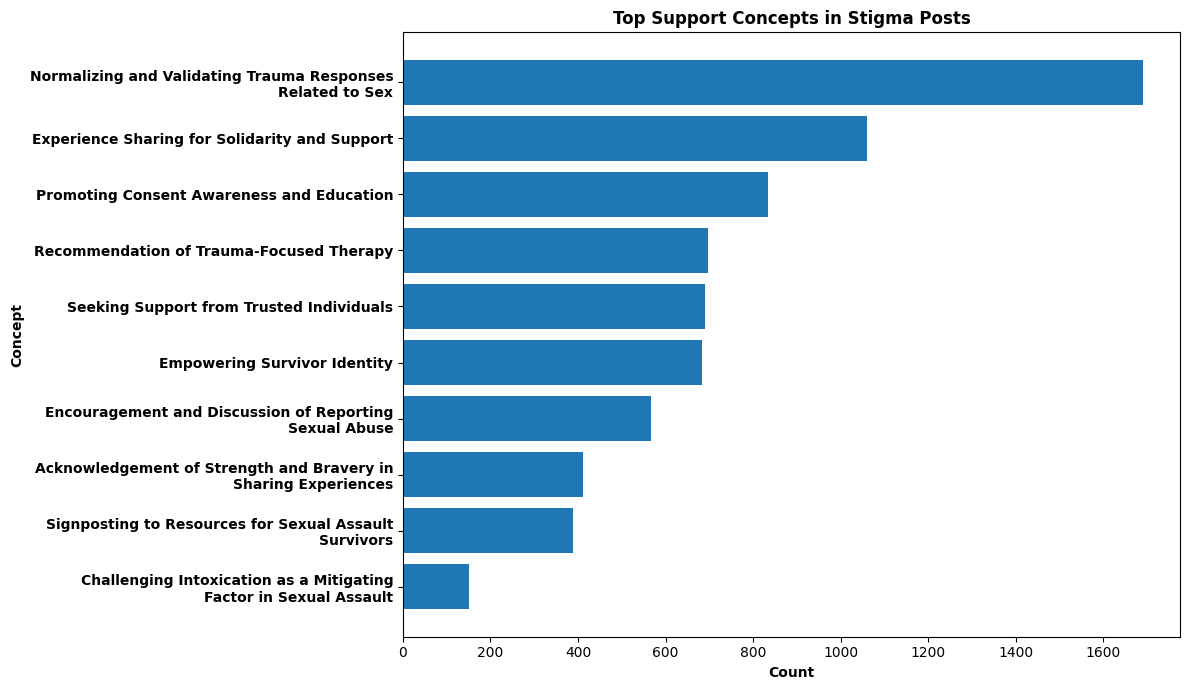

In [ ]:
concept_barplot(
    stigma_concept_summary,
    "Top Stigma Concepts",
    top_n=10,
    save_path="/content/lloom_gemini_sv_outputs/top_stigma_concepts.pdf"
)

concept_barplot(
    support_concept_summary,
    "Top Support Concepts in Stigma Posts",
    top_n=10,
    save_path="/content/lloom_gemini_sv_outputs/top_support_concepts.pdf"
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil

src = "/content/lloom_gemini_sv_outputs"
dst = "/content/drive/MyDrive/LLooM_ops"

shutil.copytree(src, dst)

'/content/drive/MyDrive/LLooM_ops'

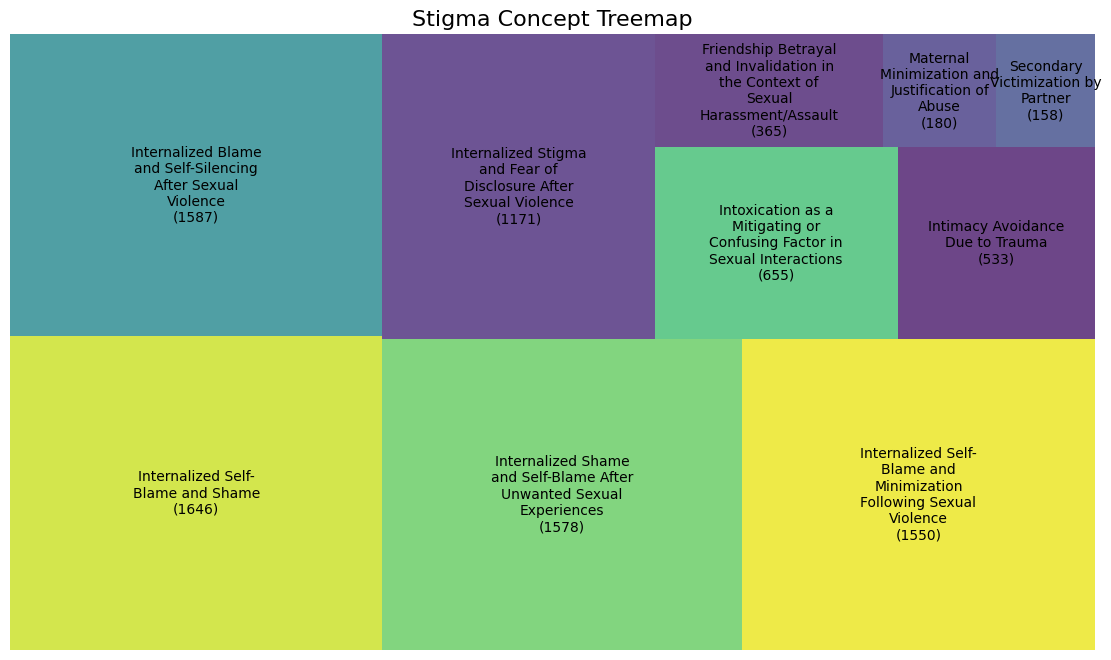

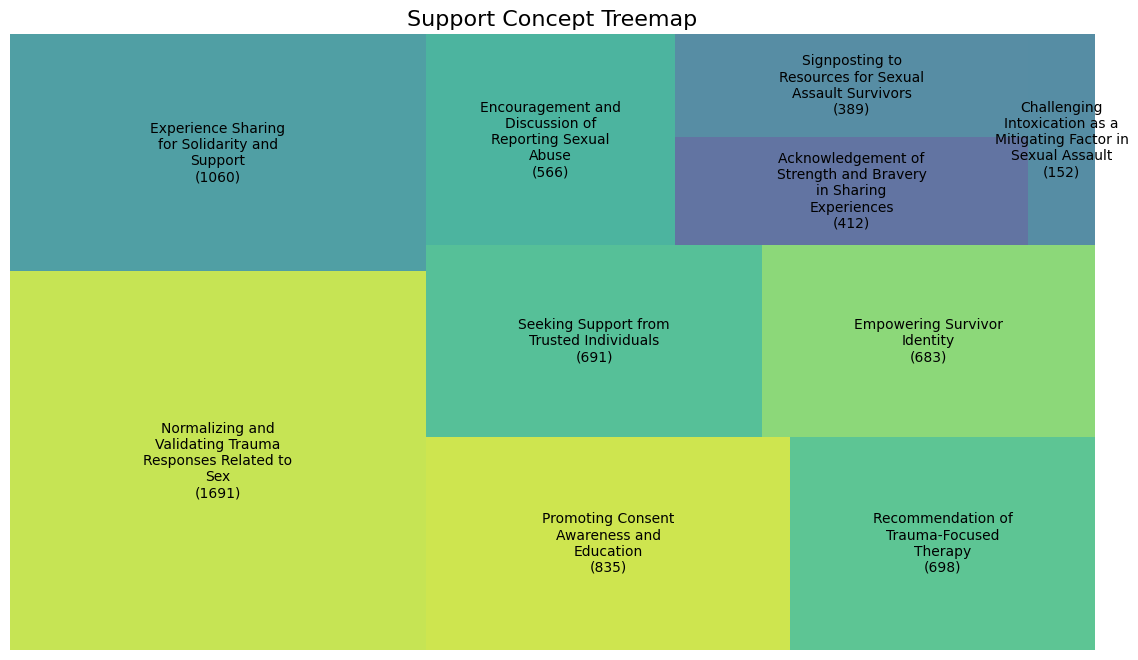

In [ ]:
def concept_treemap(df, title, top_n=10):
    plot_df = df.sort_values("matched_count", ascending=False).head(top_n).copy()

    labels = [
        "\n".join(textwrap.wrap(str(name), width=20)) + f"\n({count})"
        for name, count in zip(plot_df["concept_name"], plot_df["matched_count"])
    ]

    plt.figure(figsize=(14, 8))
    squarify.plot(
        sizes=plot_df["matched_count"],
        label=labels,
        alpha=0.8
    )
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

concept_treemap(stigma_concept_summary, "Stigma Concept Treemap", top_n=10)
concept_treemap(support_concept_summary, "Support Concept Treemap", top_n=10)

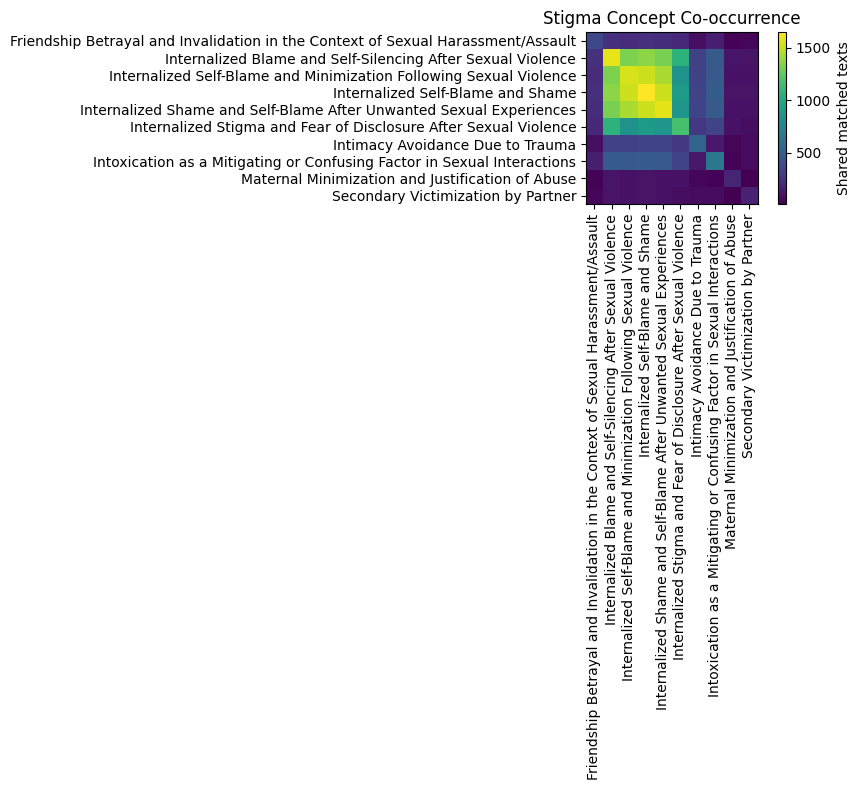

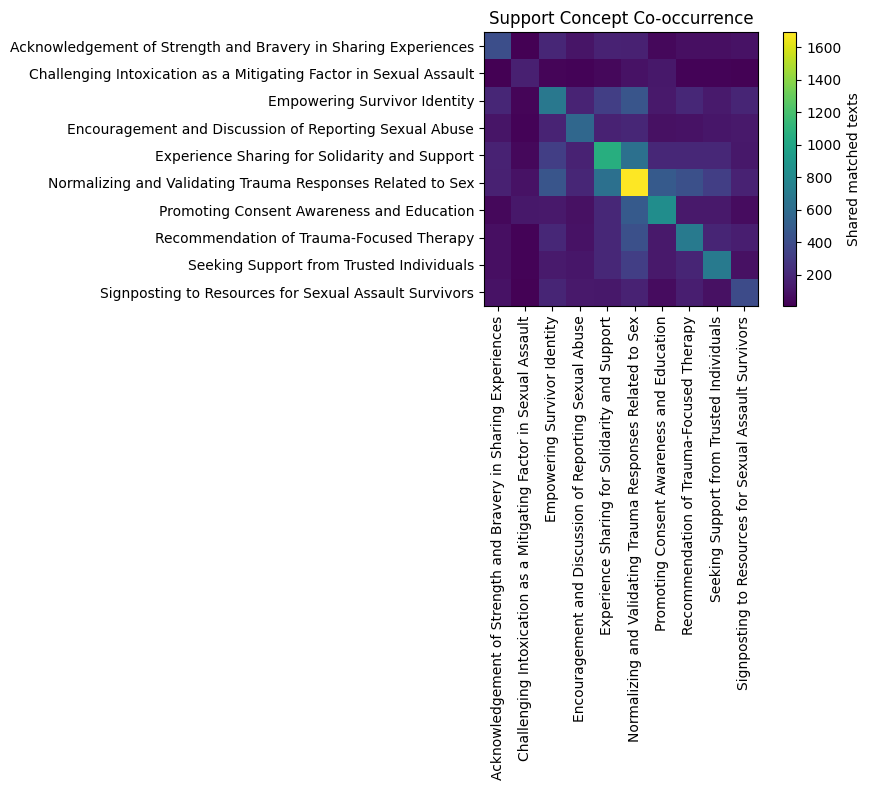

In [ ]:
def concept_cooccurrence_heatmap(scores_df, title, top_n=10):
    matched = scores_df[scores_df["match"] == 1].copy()

    top_concepts = matched["concept_name"].value_counts().head(top_n).index.tolist()
    matched = matched[matched["concept_name"].isin(top_concepts)]

    binary = pd.crosstab(matched["orig_index"], matched["concept_name"])
    cooc = binary.T.dot(binary)

    plt.figure(figsize=(10, 8))
    plt.imshow(cooc, interpolation="nearest")
    plt.colorbar(label="Shared matched texts")
    plt.xticks(range(len(cooc.columns)), cooc.columns, rotation=90)
    plt.yticks(range(len(cooc.index)), cooc.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()

concept_cooccurrence_heatmap(stigma_scores, "Stigma Concept Co-occurrence")
concept_cooccurrence_heatmap(support_scores, "Support Concept Co-occurrence")